In [42]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline

In [43]:
data = pd.read_parquet('scr_mk27/bulge-ages-and-orbits/data/APOKASC3_x_astraASPCAP.parquet')
data.head()

,KIC,EvolSt,EvolSrc,CatTab,SeisSrc,SpecSrc,NNumax,NDNu,Quar,Numax,...,raw_e_ti_h,raw_v_h,raw_e_v_h,source_pk,v_astra,t_elapsed,t_overhead,tag,l_calc,b_calc
0,893214,RGB,Seis,Gold,WAvg,DR17,8,5,15,40.5841,...,0.002236,-0.681,0.001,17208450,8000,NaN,0.0,,69.295838,9.667137
1,1026180,RC,Spec,Gold,WAvg,DR17,8,5,4,35.6089,...,0.001414,0.069,0.001,17207423,8000,NaN,0.0,,69.345008,9.842660
2,1026309,RGB,Seis,Silver,WAvg,DR17,8,4,18,16.6974,...,0.001414,-0.237,0.001,17207933,8000,NaN,0.0,,69.331078,9.809134
3,1026452,RC,Seis,Gold,WAvg,DR17,8,5,18,34.3652,...,0.004472,-0.279,0.002,17206106,8000,NaN,0.0,,69.395146,9.810321
4,1027110,RGB,Seis,Silver,WAvg,DR17,8,4,18,6.5198,...,0.001414,-0.411,0.001,17207524,8000,NaN,0.0,,69.411737,9.688373


In [44]:
spectra = pd.read_parquet('scr_mk27/bulge-ages-and-orbits/data/spectra_apokacs3.parquet')
spectra.head()

,spectrum_pk,release,sdss_id,telescope,snr,spectrum_flags,continuum,v_rad,e_v_rad,std_v_rad,median_e_v_rad,xcorr_v_rad,wavelength,flux,ivar,pixel_flags
0,35213516,dr17,66632866,apo25m,NaN,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",NaN,NaN,NaN,NaN,NaN,"[15100.802, 15101.01, 15101.219, 15101.428, 15...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,75712610,dr17,66632875,apo25m,152.848892,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",-4.786460,0.041011,0.104769,NaN,NaN,"[15100.802, 15101.01, 15101.219, 15101.428, 15...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,75698836,dr17,66632876,apo25m,387.332458,8390656,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",-28.297228,0.165555,3.140601,NaN,NaN,"[15100.802, 15101.01, 15101.219, 15101.428, 15...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,45664982,dr17,66632905,apo25m,NaN,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",NaN,NaN,NaN,NaN,NaN,"[15100.802, 15101.01, 15101.219, 15101.428, 15...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,41613346,dr17,66647106,apo25m,NaN,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",NaN,NaN,NaN,NaN,NaN,"[15100.802, 15101.01, 15101.219, 15101.428, 15...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [45]:
spectra['release'].value_counts()

release
dr17     14217
sdss5     1514
Name: count, dtype: int64

In [46]:
spec_best = (
    spectra.sort_values("snr", ascending=False)
           .drop_duplicates(subset="sdss_id", keep="first")
)
merged = data.merge(spec_best, on="sdss_id", how="left", suffixes=('', '_spec'))

In [47]:
merged['EvolSt'].value_counts()

EvolSt
RGB        9631
RC         5735
Dwarf       241
Unknown     166
RC/RGB       29
Name: count, dtype: int64

In [52]:
merged['mg_fe'] = merged['raw_mg_h'] - merged['raw_fe_h']
merged['ca_fe'] = merged['raw_ca_h'] - merged['raw_fe_h']
merged['al_fe'] = merged['raw_al_h'] - merged['raw_fe_h']
merged['c_fe'] = merged['raw_c_h'] - merged['raw_fe_h']
merged['n_fe'] = merged['raw_n_h'] - merged['raw_fe_h']
merged['o_fe'] = merged['raw_o_h'] - merged['raw_fe_h']
merged['ce_fe'] = merged['raw_ce_h'] - merged['raw_fe_h']
merged['nd_fe'] = merged['raw_nd_h'] - merged['raw_fe_h']

# Error on [X/Fe] = sqrt( (e_X)^2 + (e_Fe)^2 ), assuming errors are uncorrelated
merged['e_mg_fe'] = np.sqrt(merged['raw_e_mg_h']**2 + merged['raw_e_fe_h']**2)
merged['e_ca_fe'] = np.sqrt(merged['raw_e_ca_h']**2 + merged['raw_e_fe_h']**2)
merged['e_al_fe'] = np.sqrt(merged['raw_e_al_h']**2 + merged['raw_e_fe_h']**2)
merged['e_c_fe']  = np.sqrt(merged['raw_e_c_h']**2  + merged['raw_e_fe_h']**2)
merged['e_n_fe']  = np.sqrt(merged['raw_e_n_h']**2  + merged['raw_e_fe_h']**2)
merged['e_o_fe']  = np.sqrt(merged['raw_e_o_h']**2  + merged['raw_e_fe_h']**2)
merged['e_ce_fe'] = np.sqrt(merged['raw_e_ce_h']**2 + merged['raw_e_fe_h']**2)
merged['e_nd_fe'] = np.sqrt(merged['raw_e_nd_h']**2 + merged['raw_e_fe_h']**2)

In [ ]:
merged.to_parquet('scr_mk27/bulge-ages-and-orbits/data/apokacs_with_spectra_raw.parquet')

# RGB/RC stars

In [54]:
rgb = merged[merged['EvolSt'] == 'RGB']

In [55]:
[c for c in rgb.columns if 'age' in c.lower()]

['AgeCat', 'AgeRGB', 'E_AgeRGB', 'e_AgeRGB', 'AgeRC', 'E_AgeRC', 'e_AgeRC']

In [56]:
filt = rgb.dropna(subset=['AgeRGB', 'e_AgeRGB', 'E_AgeRGB'])

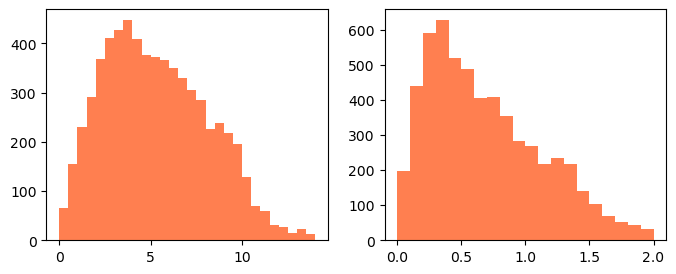

In [57]:
filt = filt[(filt['AgeRGB'] < 14) & (filt['E_AgeRGB'] < 20) & (filt['e_AgeRGB'] > -20)]
sigma_age = (filt['E_AgeRGB'] - filt['e_AgeRGB']) / 2   # == (|e_AgeRGB| + E_AgeRGB)/2
filt['AgeRGB_err'] = sigma_age
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(8, 3))
ax[0].hist(filt['AgeRGB'], bins=np.linspace(0, 14, 29), color='coral');
ax[1].hist(filt['AgeRGB_err'], bins=np.linspace(0, 2, 21), color='coral');

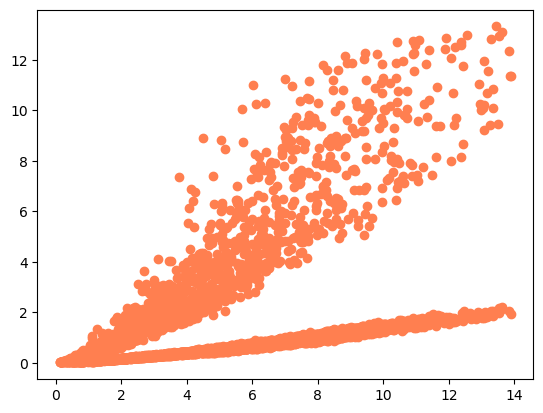

In [58]:
plt.scatter(filt['AgeRGB'], filt['AgeRGB_err'], color='coral');

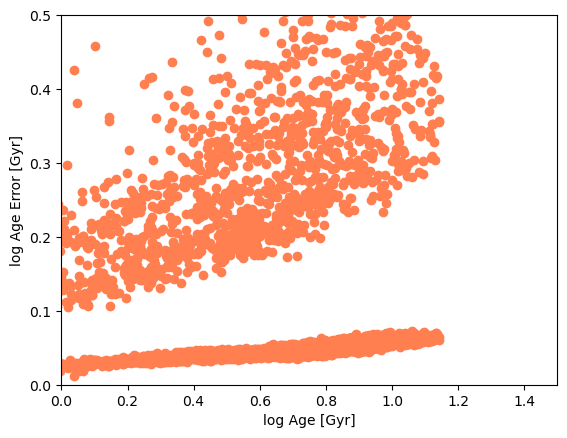

In [59]:
filt['logAgeRGB'] = np.log10(filt['AgeRGB'])
filt['logAgeRGB_err'] = filt['AgeRGB_err'] / filt['AgeRGB'] / np.log(10)
plt.scatter(filt['logAgeRGB'], filt['logAgeRGB_err'], color='coral');
plt.xlabel('log Age [Gyr]');
plt.ylabel('log Age Error [Gyr]');
plt.xlim(0, 1.5);
plt.ylim(0, 0.5);


In [60]:
LABEL_COLS = (['raw_teff', 'raw_logg', 'raw_fe_h', 'mg_fe']
              + ['c_fe', 'n_fe', 'al_fe', 'ce_fe', 'nd_fe']
              + ['o_fe'])

In [62]:
for lc in LABEL_COLS:
    filt = filt[(filt[lc].notna()) & (filt[lc] > -100)]

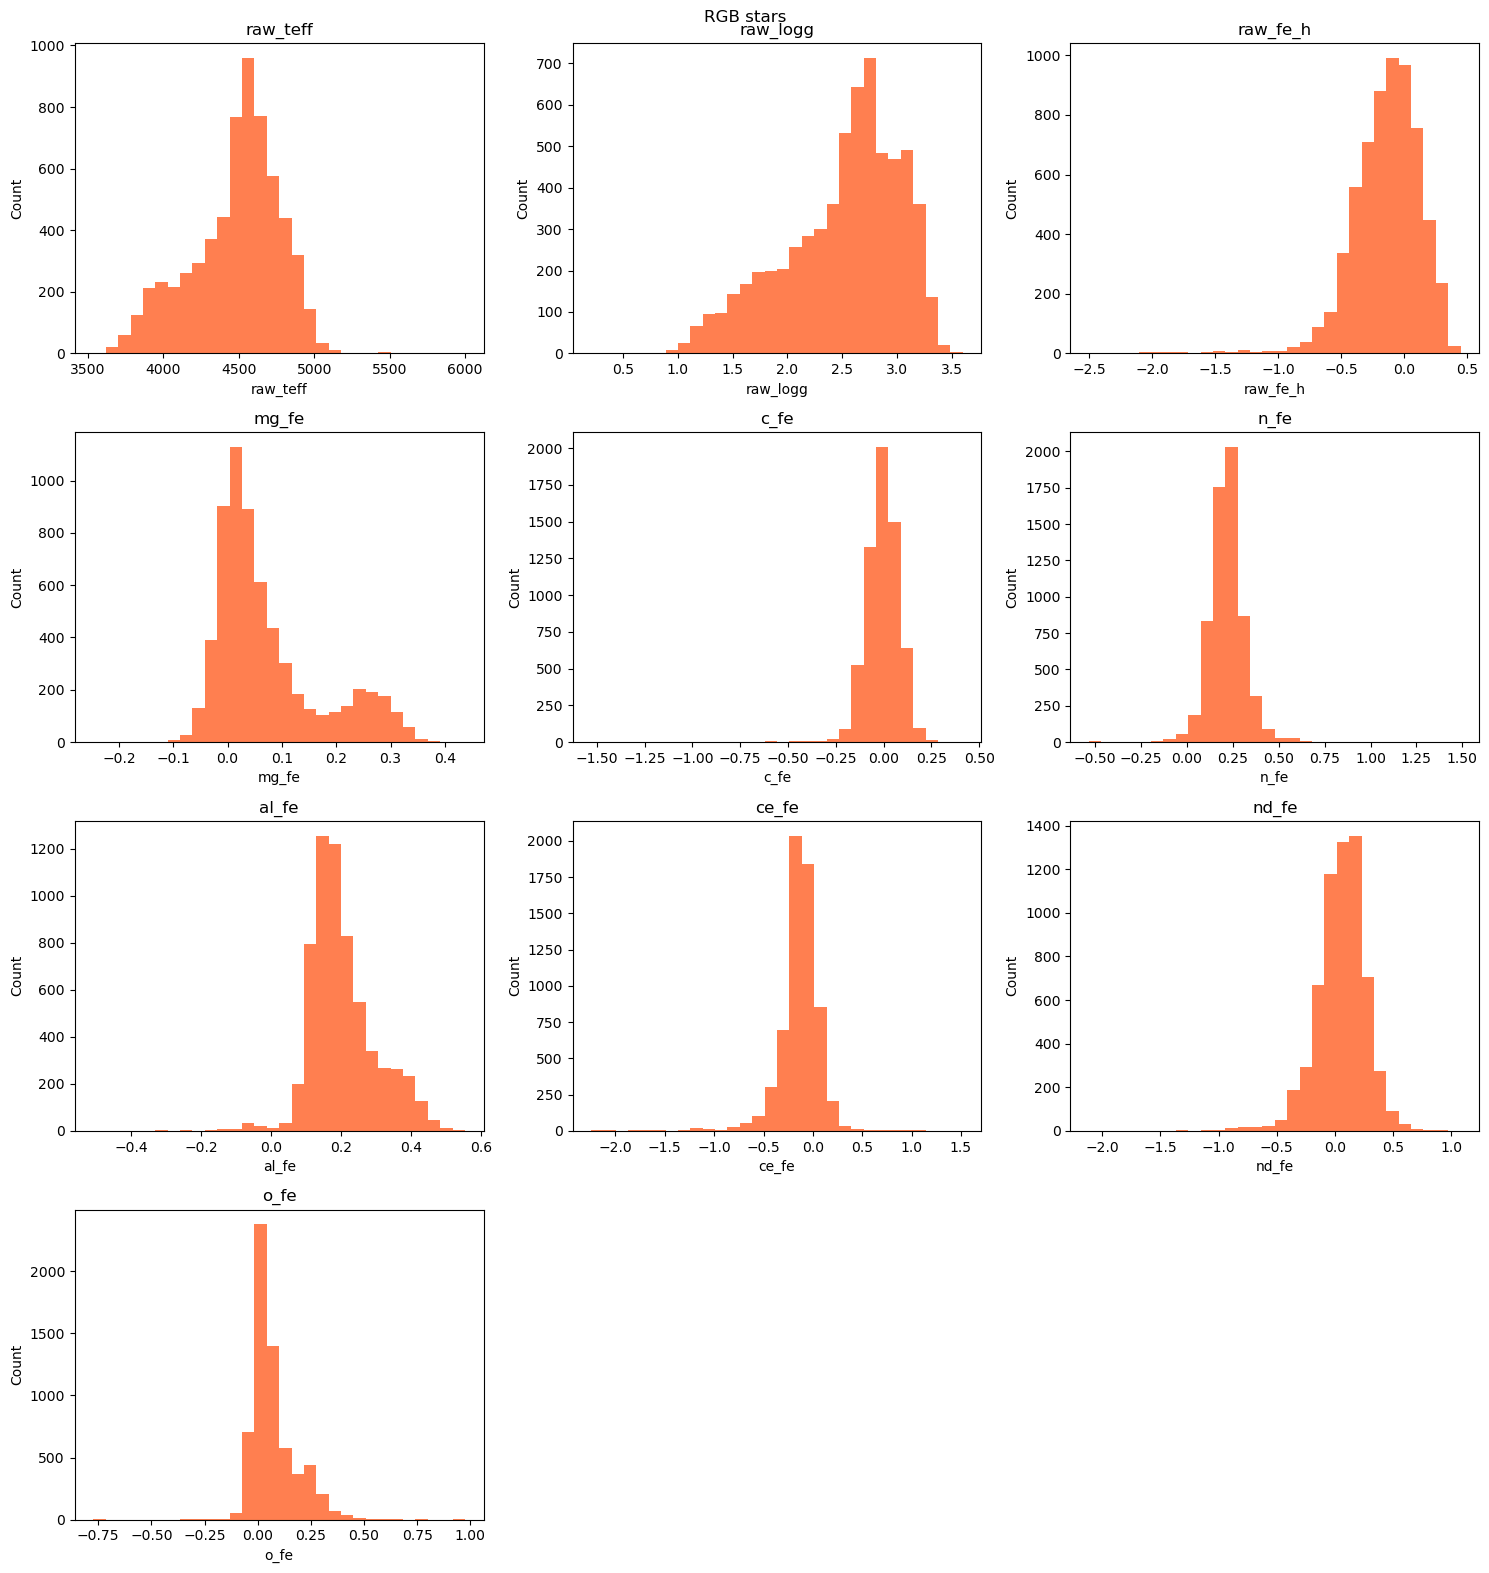

In [63]:
# Automatically plot all label columns as histograms in subplots

num_labels = len(LABEL_COLS)
ncols = 3
nrows = (num_labels + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(LABEL_COLS):
    axes[i].hist(filt[col].dropna(), bins=30, color='coral')
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('RGB stars')
plt.tight_layout()
plt.show()

In [64]:
filt.to_parquet('scr_mk27/bulge-ages-and-orbits/data/apokacs_rgb_filt.parquet')

# RC

In [65]:
rc = merged[merged['EvolSt'] == 'RC']

In [69]:
filt = rc.dropna(subset=['AgeRC', 'e_AgeRC', 'E_AgeRC'])

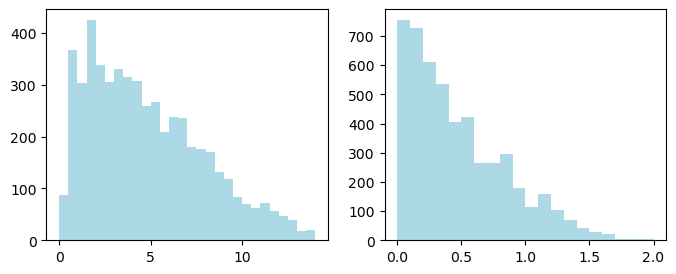

In [70]:
filt = filt[(filt['AgeRC'] < 14) & (filt['E_AgeRC'] < 20) & (filt['e_AgeRC'] > -20)]
sigma_age = (filt['E_AgeRC'] - filt['e_AgeRC']) / 2   # == (|e_AgeRGB| + E_AgeRGB)/2
filt['AgeRC_err'] = sigma_age
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(8, 3))
ax[0].hist(filt['AgeRC'], bins=np.linspace(0, 14, 29), color='lightblue');
ax[1].hist(filt['AgeRC_err'], bins=np.linspace(0, 2, 21), color='lightblue');

In [71]:
LABEL_COLS = (['raw_teff', 'raw_logg', 'raw_fe_h', 'mg_fe']
              + ['c_fe', 'n_fe', 'al_fe', 'ce_fe', 'nd_fe']
              + ['o_fe'])
for lc in LABEL_COLS:
    filt = filt[(filt[lc].notna()) & (filt[lc] > -100)]
# Automatically plot all label columns as histograms in subplots

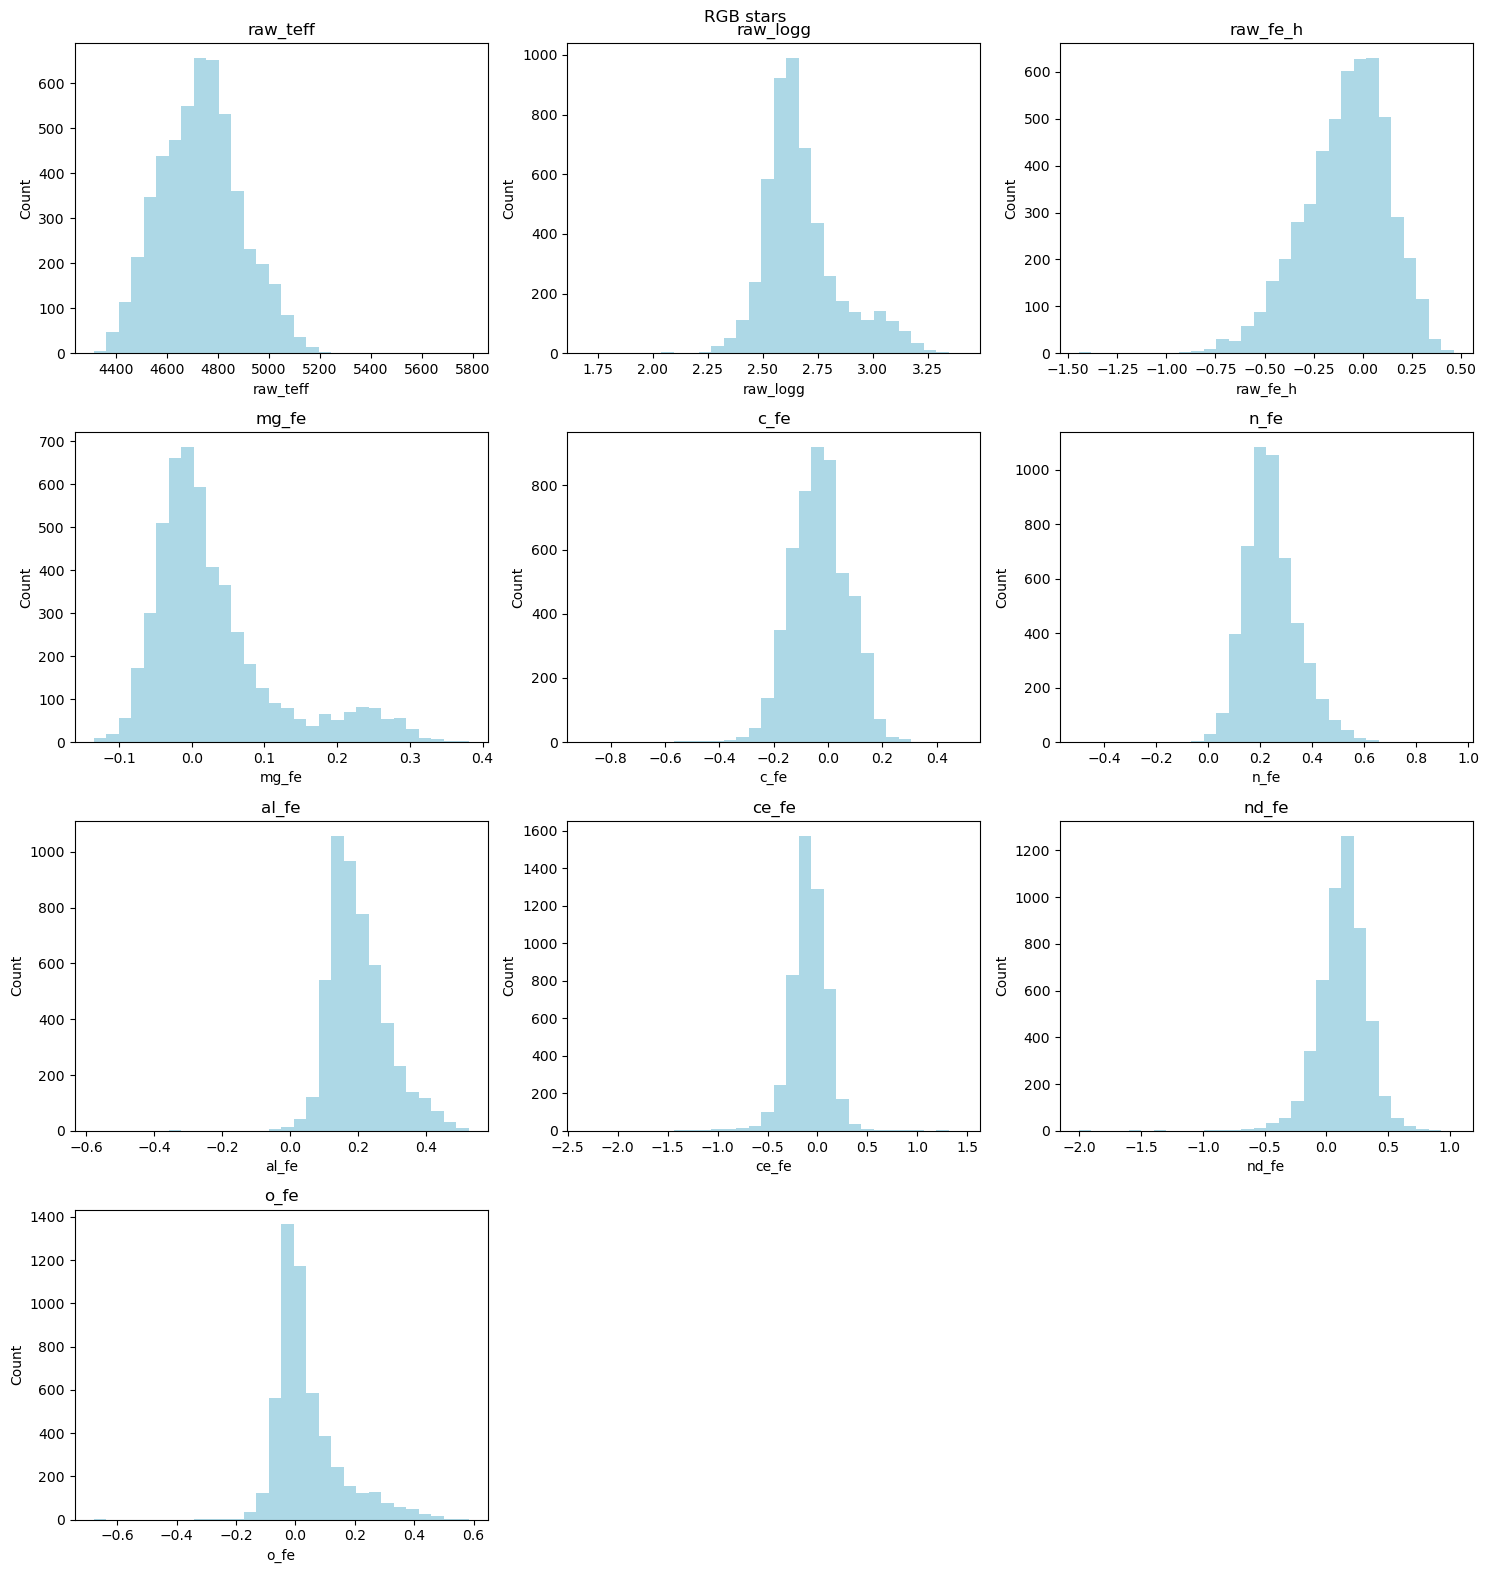

In [72]:
# Automatically plot all label columns as histograms in subplots

num_labels = len(LABEL_COLS)
ncols = 3
nrows = (num_labels + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(LABEL_COLS):
    axes[i].hist(filt[col].dropna(), bins=30, color='lightblue')
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('RGB stars')
plt.tight_layout()
plt.show()

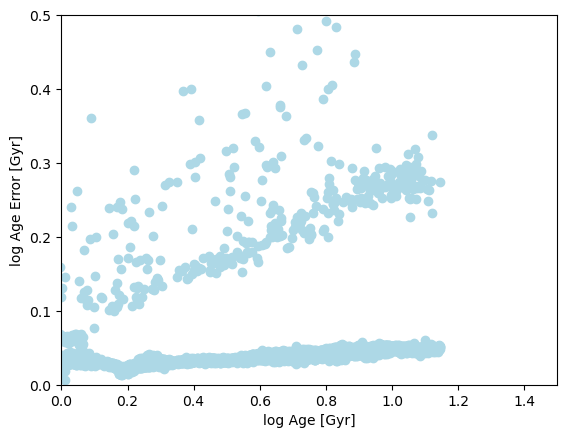

In [75]:
filt['logAgeRC'] = np.log10(filt['AgeRC'])
filt['logAgeRC_err'] = filt['AgeRC_err'] / filt['AgeRC'] / np.log(10)
plt.scatter(filt['logAgeRC'], filt['logAgeRC_err'], color='lightblue');
plt.xlabel('log Age [Gyr]');
plt.ylabel('log Age Error [Gyr]');
plt.xlim(0, 1.5);
plt.ylim(0, 0.5);

In [76]:
filt.to_parquet('scr_mk27/bulge-ages-and-orbits/data/apokacs_rc_filt.parquet')

# Export for BNN training

Write BNN-ready CSVs matching the schema that `bingo-modern/prepare_dataset.py`
and `train_pipeline.ipynb` expect:

- **ID**: `APOGEE_ID`  **dedup**: `SNR`
- **target**: `logAge`, `logAgeErr`
- **features**: `LOGG`, `TEFF`, `MG_FE`, `FE_H`, `C_FE`, `N_FE` (+ a `*_ERR` for each)

The pipeline derives `[C/N]` and `age = 10**logAge` itself, standardizes features
with train-only stats, and splits train/test — so we only supply raw (unnormalized)
columns here. Ages are symmetrized (`(E - e)/2`, since `e_Age*` is stored negative)
and propagated to log10.

In [77]:
BNN_OUT_DIR = 'scr_mk27/bulge-ages-and-orbits/data'

# BNN feature name -> (value column, error column) in `merged`
FEATURE_MAP = {
    'LOGG':  ('raw_logg', 'raw_e_logg'),
    'TEFF':  ('raw_teff', 'raw_e_teff'),
    'FE_H':  ('raw_fe_h', 'raw_e_fe_h'),
    'MG_FE': ('mg_fe',    'e_mg_fe'),
    'C_FE':  ('c_fe',     'e_c_fe'),
    'N_FE':  ('n_fe',     'e_n_fe'),
}


def to_bnn_frame(df, age_col):
    """Build a BNN-ready frame for one evolutionary state.

    `age_col` is 'AgeRGB' or 'AgeRC'; its lower/upper errors are `e_<col>` (negative)
    and `E_<col>` (positive). Ages are symmetrized then propagated to log10 space.
    """
    e, E = f'e_{age_col}', f'E_{age_col}'
    d = df.dropna(subset=[age_col, e, E]).copy()
    # drop sentinel / unphysical ages and error placeholders
    d = d[(d[age_col] < 14) & (d[E] < 20) & (d[e] > -20)]
    age_err = (d[E] - d[e]) / 2  # symmetric 1-sigma (e_ is stored negative)

    out = pd.DataFrame({'APOGEE_ID': d['APOGEE_ID'].values, 'SNR': d['snr'].values})
    for name, (col, ecol) in FEATURE_MAP.items():
        out[name] = d[col].values
        out[f'{name}_ERR'] = d[ecol].values
    out['logAge'] = np.log10(d[age_col].values)
    out['logAgeErr'] = age_err.values / d[age_col].values / np.log(10)

    # clean_labels requires complete rows and strictly positive errors
    out = out.replace([np.inf, -np.inf], np.nan).dropna()
    err_cols = [c for c in out.columns if c.endswith('_ERR')] + ['logAgeErr']
    return out[(out[err_cols] > 0).all(axis=1)].reset_index(drop=True)


rgb_bnn = to_bnn_frame(merged[merged['EvolSt'] == 'RGB'], 'AgeRGB')
rc_bnn = to_bnn_frame(merged[merged['EvolSt'] == 'RC'], 'AgeRC')

rgb_bnn.to_csv(f'{BNN_OUT_DIR}/apokacs_rgb_bnn.csv', index=False)
rc_bnn.to_csv(f'{BNN_OUT_DIR}/apokacs_rc_bnn.csv', index=False)
print(f'RGB -> {len(rgb_bnn)} stars  |  RC -> {len(rc_bnn)} stars')
rgb_bnn.head()

RGB -> 5660 stars  |  RC -> 5017 stars


,APOGEE_ID,SNR,LOGG,LOGG_ERR,TEFF,TEFF_ERR,FE_H,FE_H_ERR,MG_FE,MG_FE_ERR,C_FE,C_FE_ERR,N_FE,N_FE_ERR,logAge,logAgeErr
0,2M19245967+3638183,254.708313,2.562,0.006,4641.774902,2.834,-0.247,0.001,0.067,0.002449,-0.059,0.002449,0.261,0.003000,0.459619,0.042344
1,2M19242636+3643594,335.212860,2.462,0.003,4396.932129,1.133,0.126,0.001,-0.041,0.001732,-0.077,0.001732,0.312,0.001732,-0.233438,0.095564
2,2M19250937+3644599,333.051086,1.844,0.004,4083.518066,0.515,-0.320,0.001,0.279,0.001732,0.141,0.001732,0.151,0.002449,0.957579,0.284163
3,2M19252021+3647118,259.065002,2.942,0.004,4560.104004,1.929,0.180,0.001,0.028,0.002449,0.063,0.002449,0.300,0.002449,0.767297,0.041560
4,2M19244752+3649583,488.277008,1.856,0.004,4240.509766,0.567,-0.395,0.001,0.044,0.001732,-0.059,0.001732,0.268,0.002449,-0.363913,0.078406
